Chapter 29
# Scikit-Learn生成样本数据集
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler # StandardScaler()。StandardScaler()是
                           # scikit-learn 中的一个预处理类，用于在机器学习流程中对数据进行标准化处理
from sklearn.datasets import make_circles, make_moons
from sklearn.datasets import make_blobs, make_classification

##图像

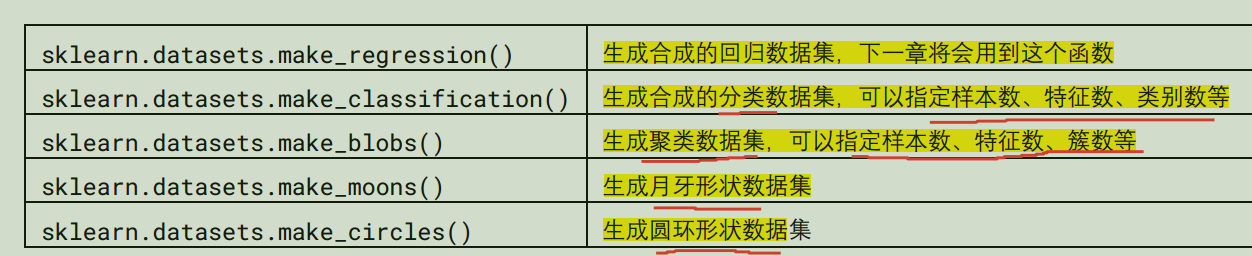

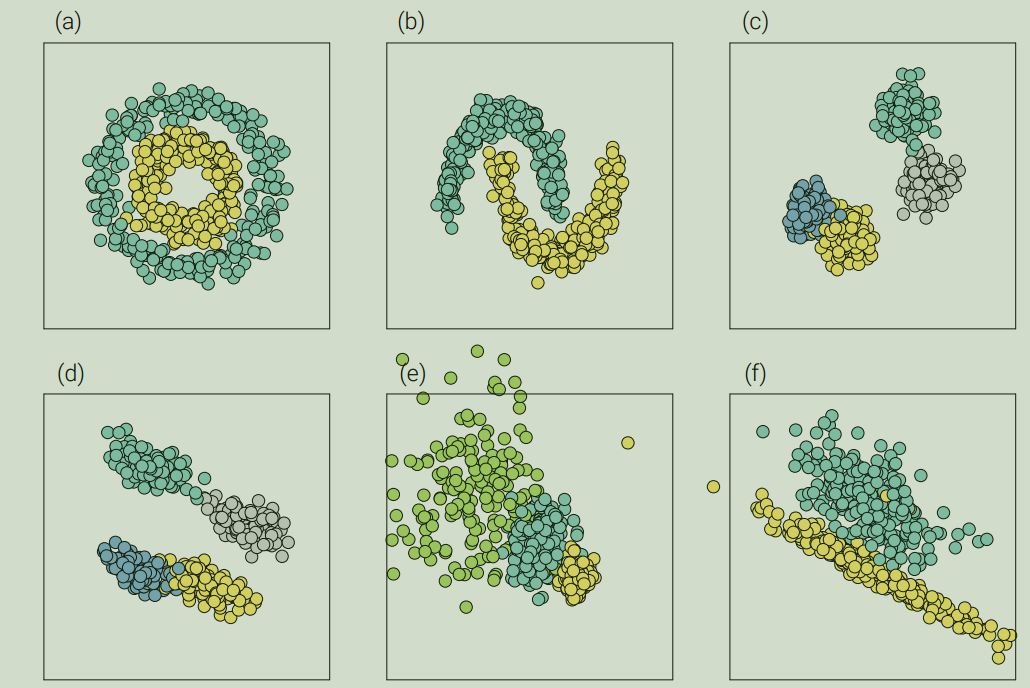

#样本数量

从 sklearn.preprocessing 模块导入 StandardScaler()。StandardScaler()是
scikit-learn 中的一个预处理类，用于在机器学习流程中对数据进行标准化处理。


标准化 (standardization) 是数据预处理的一种常见方式，目的是将数据的特征值缩放成均
值为 0，标准差为 1 的分布，即计算 Z 分数 (Z score)，以消除不同特征之间的尺度差异。本章后文
将介绍更多预处理方法。

In [3]:
n_samples = 500 #样本数量

##产生环形数据集

sklearn.datasets.make_circles() 生成环形数据集的函数，结果如图 1 (a) 所
示。数据点位于两个同心圆上，可以用于测试机器学习算法。

参数 n_samples 设定数据点数量，默认为 100。

参数 noise 为添加到数据中的高斯噪声的标准差。

参数 factor 为内外圆之间的比例因子。factor 取值在 0 到 1 之间，0.0 表示两个圆重叠，1.0

表示完全分离的两个圆。


In [5]:
# 产生环形数据集

# n_samples：样本数据； factor: 内外圆的比例因子；noise：添加到数据中的高斯噪声的标准差
circles = make_circles(n_samples=n_samples,
                       factor=0.5, noise=0.1)

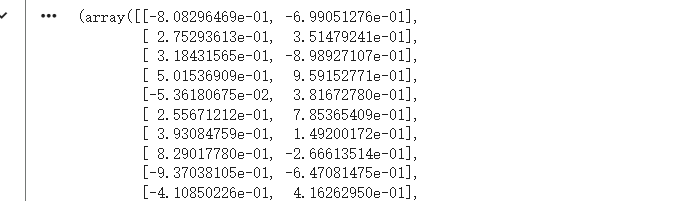

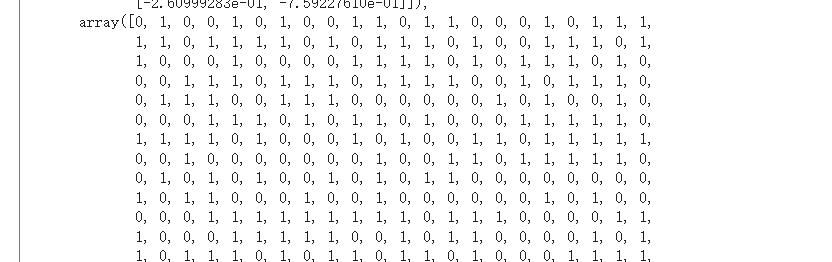

### circles生成的数据为一个元组；（data, lables）

In [8]:
print(type(circles))

<class 'tuple'>


##产生月牙形状数据集

中 sklearn.datasets.make_moons() 用于生成月牙形状的数据集，结果如图 1 (b) 所
示。这个函数可以用于测试在非线性数据上表现良好的算法。

参数 n_samples 指定生成的数据点数量。

参数 noise 指定添加到数据中的高斯噪声的标准差。


In [10]:
# 产生月牙形状数据集
moons = make_moons(n_samples=n_samples,
                   noise=0.1)

In [12]:
print(type(moons)) # 与circle类似也是一个元组

<class 'tuple'>


##make_blobs() 生成一个由多个高斯分布组成的数据集，

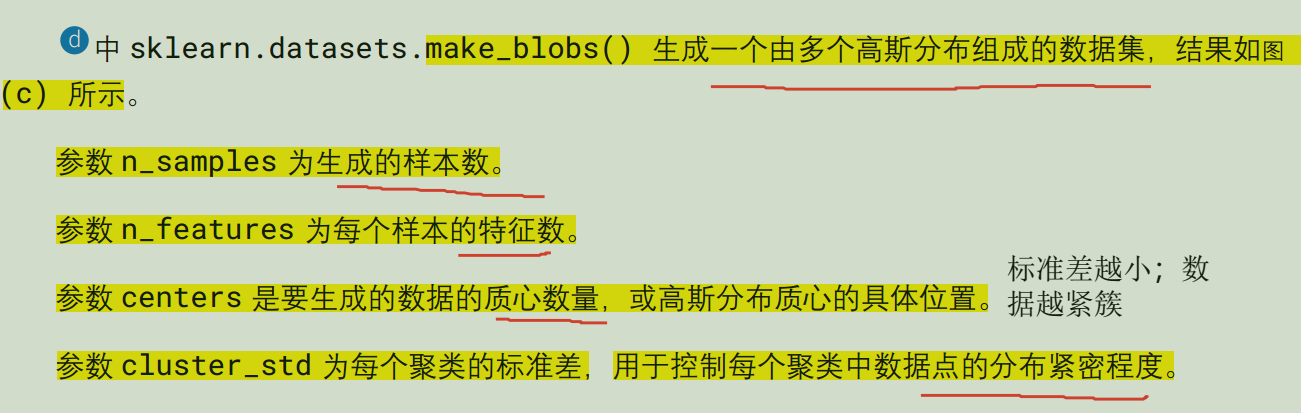

n_samples：应该是之前定义的变量，表示总样本数。


centers=4：生成 4 个簇（聚类中心）。


cluster_std=1.5：每个簇内样本的标准差（离散程度），值越大簇越分散。


返回值 blobs 是一个元组 (data, labels)：


blobs[0]：形状为 (n_samples, 2) 的特征矩阵（二维数据）。


blobs[1]：形状为 (n_samples,) 的标签向量（每个样本属于哪个簇）。

In [13]:
#
blobs = make_blobs(n_samples=n_samples,
                   centers = 4,
                   cluster_std = 1.5)

##几何变换

In [14]:
blobs[0].shape

(500, 2)

In [16]:
# 几何变换
transformation = [[0.4, 0.2], [-0.4, 1.2]]
X = np.dot(blobs[0], transformation) # 对数据进行缩放 + 旋转
# 500*2 与 2*2 --》为500*2
rotated = (X,blobs[1]) # 将变换后的数据再次与标签组合成元组

In [18]:
print(type(rotated)) # 与 blobs相类似

<class 'tuple'>


##不同稀疏程度

在利用 sklearn.datasets.make_blobs() 时，每个高斯分布指定不同的标准差，结果如图
1 (e) 所示。


In [19]:
# 不同稀疏程度
varied = make_blobs(n_samples=n_samples,
                    cluster_std=[1.0, 2.5, 0.5])
# 指定不同的标准差

In [21]:
varied[0].shape

(500, 2)

##用于测试分类算法的样本数据集

make_classification：生成用于分类的合成数据集。


参数含义：


n_samples：样本总数（需提前定义）。

n_features=2：特征维度为 2（便于二维可视化）。

n_redundant=0：无冗余特征（所有特征都有用）。

n_informative=2：2 个特征都有信息量（与 n_features 相同）。

n_clusters_per_class=1：每个类别只形成 1 个簇（数据更紧凑）。

返回值 classif 是元组 (data, labels)。

In [22]:
# 用于测试分类算法的样本数据集
classif = make_classification(n_samples=n_samples,
                              n_features=2,
                              n_redundant=0,
                              n_informative=2,
                              n_clusters_per_class=1)

circles：同心圆分布（非线性可分）

moons：半月形分布（非线性可分）

blobs：高斯簇（线性可分）

rotated：旋转后的 blobs（线性可分但方向改变）

varied：不同方差的簇（可能前面代码生成）

classif：刚生成的分类数据集（通常包含线性可分或轻度非线性

In [23]:
# 数据集
datasets = [circles, moons, blobs, rotated, varied, classif]

#可视化，有标签

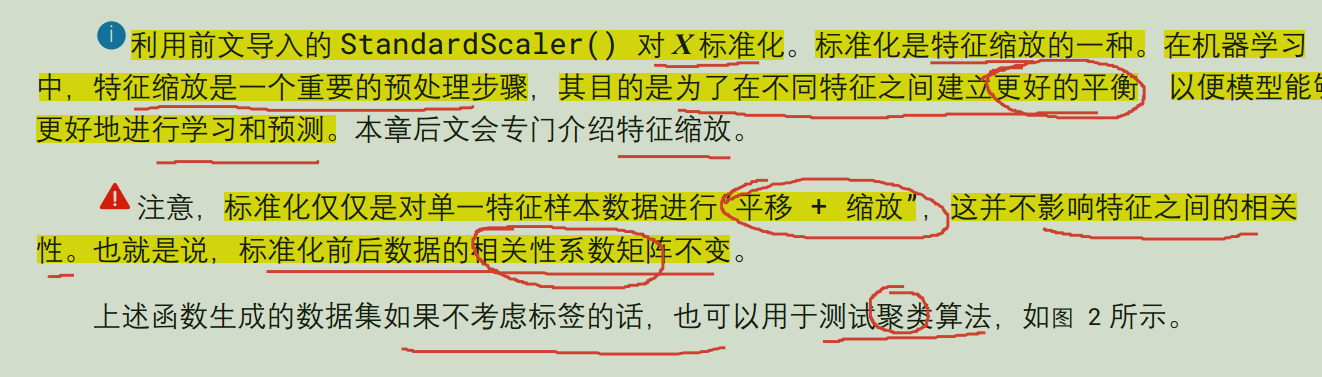

5. 标准化处理
`X = StandardScaler().fit_transform(X)`

标准化（Z-score normalization）：将每个特征转换为均值为 0、方差为 1 的标准正态分布。

公式：z = (x - μ) / σ

目的：

消除量纲影响，使所有特征处于同一尺度。

便于可视化时统一坐标轴范围（xlim(-3,3)）。

某些算法（如 SVM、KNN）对特征尺度敏感

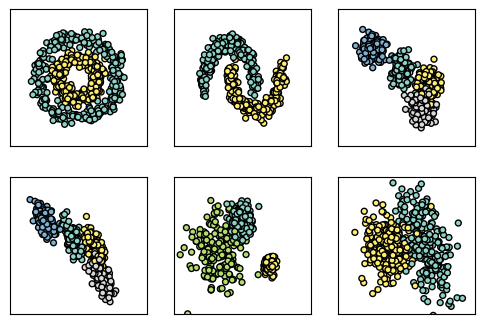

In [24]:
# 可视化，有标签
# 2*3子图
fig, axes = plt.subplots(2,3,figsize=(6,4))
axes = axes.flatten() # 展为一维数组
# 类似字典； datasets：生成的数据；数据为元组 , axes; 轴对象
for dataset_idx, ax_idx in zip(datasets, axes):

    # dataset_idx这个是一个元组；分别赋值给X（数据）,y（标签）
    # 解包每个数据集为特征 X 和标签 y。
    X, y = dataset_idx
    # 标准化
    X = StandardScaler().fit_transform(X)

    '''
  X[:, 0] 和 X[:, 1]：第一个和第二个特征作为横纵坐标。
  s=18：点的大小。
  c=y：根据标签着色。
  cmap='Set3'：使用 Set3 颜色映射（柔和的 12 色系）。
  edgecolors="k"：点的边缘颜色为黑色，增加区分度。

    '''
    # 绘制散点图
    ax_idx.scatter(X[:, 0], X[:, 1], s=18,
               c=y, cmap='Set3',
               edgecolors="k")

    ax_idx.set_xlim(-3, 3) # 范围
    ax_idx.set_ylim(-3, 3)
    ax_idx.set_xticks(())  #隐藏刻度标签，使画面更简洁
    ax_idx.set_yticks(())
    ax_idx.set_aspect('equal', adjustable='box') # 保持横纵轴比例相等（1:1），避免图形拉伸变形。
#adjustable='box'：调整绘图区域以适应等比例约束

circles：同心圆分布（非线性可分）

moons：半月形分布（非线性可分）

blobs：高斯簇（线性可分）

rotated：旋转后的 blobs（线性可分但方向改变）

varied：不同方差的簇（可能前面代码生成）

classif：刚生成的分类数据集（通常包含线性可分或轻度非线性

#可视化，无标签

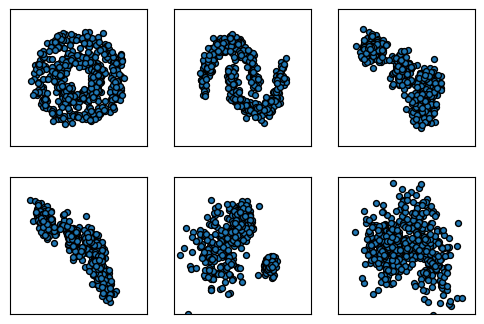

In [25]:
# 可视化，无标签
fig, axes = plt.subplots(2,3,figsize=(6,4))
axes = axes.flatten()

for dataset_idx, ax_idx in zip(datasets, axes):

    X, y = dataset_idx
    X = StandardScaler().fit_transform(X)
    # 没有标签；c=y
    ax_idx.scatter(X[:, 0], X[:, 1], s=18,
               edgecolors="k")
    # ax_idx.scatter(X[:, 0], X[:, 1], s=18, c=y, cmap='Set3', edgecolors="k")
    ax_idx.set_xlim(-3, 3)
    ax_idx.set_ylim(-3, 3)
    ax_idx.set_xticks(())
    ax_idx.set_yticks(())
    ax_idx.set_aspect('equal', adjustable='box')